In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

100%|██████████| 12.4k/12.4k [00:00<00:00, 18.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/redwankarimsony/heart-disease-data/versions/6


In [ ]:
df_o = pd.read_csv(path+  "/heart_disease_uci.csv")
df_o.head(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [ ]:
df_o.shape

(920, 16)

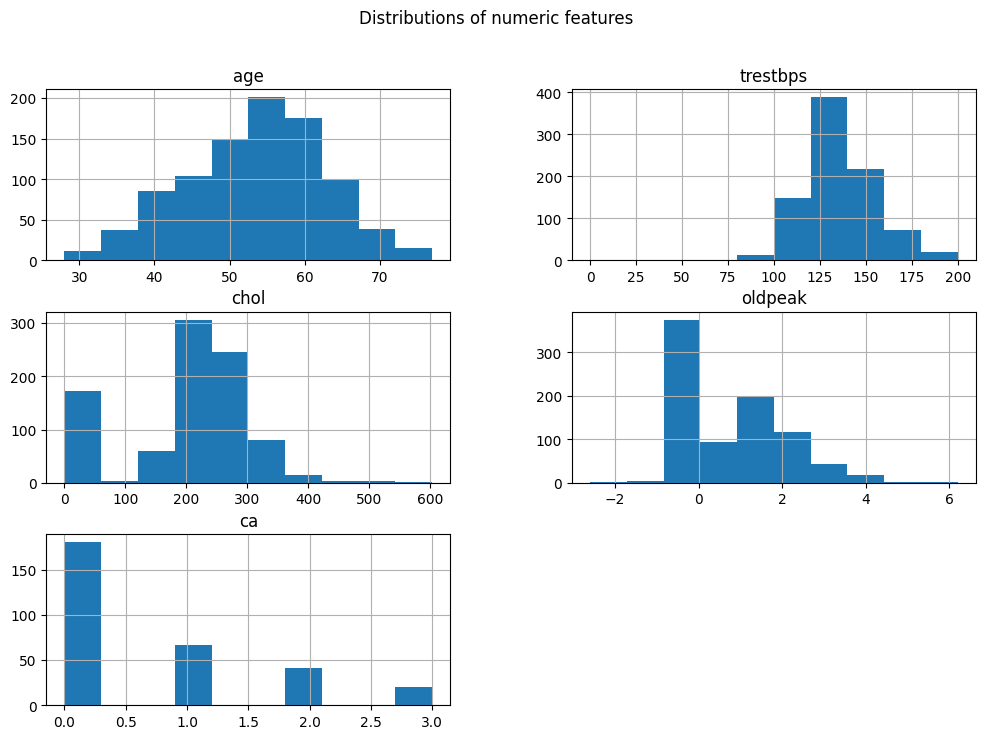

In [ ]:
numeric_cols = ['age', 'trestbps', 'chol', 'oldpeak','ca']
df_o[numeric_cols].hist(bins=10, figsize=(12, 8))
plt.suptitle("Distributions of numeric features")
plt.show()

In [ ]:
df_o.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df_o['dataset'].value_counts()

,count
dataset,
Cleveland,304
Hungary,293
VA Long Beach,200
Switzerland,123


In [ ]:
df_o.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [ ]:
df = df_o.copy()

In [ ]:
drop = ['slope','ca','thal','id']
df = df.drop(drop,axis=1)

In [ ]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


In [ ]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [ ]:
df = df.assign(num_trans=df['num'].map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1}).astype('category'))
df['num_trans'].value_counts()

,count
num_trans,
1,509
0,411


In [ ]:
num_cols = ['age','trestbps','chol','thalch','oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang']

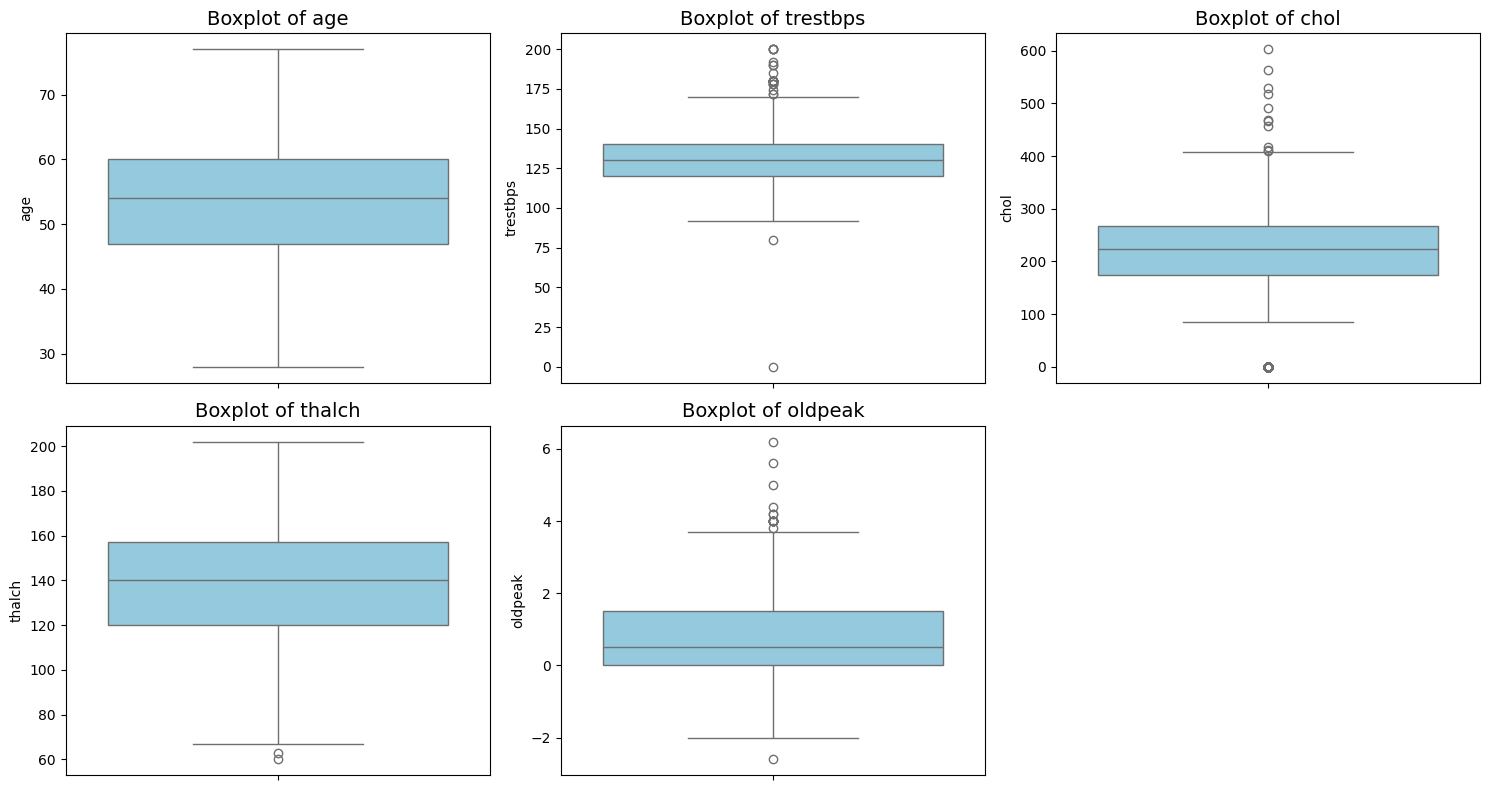

In [ ]:
plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=14)
    plt.ylabel(col)
plt.tight_layout()


In [ ]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer.fit_transform(df[cat_cols])

In [ ]:
median_chol = df['chol'].median()
df['chol'] = df['chol'].replace(0, median_chol)

median_trestbps = df['trestbps'].median()
df['trestbps'] = df['trestbps'].replace(0, median_trestbps)

In [ ]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num,num_trans
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        920 non-null    int64   
 1   sex        920 non-null    object  
 2   dataset    920 non-null    object  
 3   cp         920 non-null    object  
 4   trestbps   920 non-null    float64 
 5   chol       920 non-null    float64 
 6   fbs        920 non-null    object  
 7   restecg    920 non-null    object  
 8   thalch     920 non-null    float64 
 9   exang      920 non-null    object  
 10  oldpeak    920 non-null    float64 
 11  num        920 non-null    int64   
 12  num_trans  920 non-null    category
dtypes: category(1), float64(4), int64(2), object(6)
memory usage: 87.4+ KB


In [ ]:
df['fbs'] = df['fbs'].astype(bool)
df['exang'] = df['exang'].astype(bool)

In [ ]:
ca_col = df.select_dtypes(include=['object']).columns
ca_col

Index(['sex', 'dataset', 'cp', 'restecg'], dtype='object')

In [ ]:
df = pd.get_dummies(df, columns=ca_col, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
X = df.drop(columns =['num','num_trans'])
y = df['num_trans']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

In [ ]:
lr = LogisticRegression(class_weight='balanced', random_state=42)
dt = DecisionTreeClassifier(criterion='gini',class_weight='balanced', random_state=42)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
bnb = BernoulliNB()
svc = SVC(kernel='linear', class_weight='balanced', random_state=42)
xgb = XGBClassifier(use_label_encoder=False,eval_metric='logloss',scale_pos_weight=ratio, random_state=42)

In [ ]:
classifiers = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Naive Bayes': bnb,
    'Support Vector Machine': svc,
    'XGBoost': xgb
}


Model: Logistic Regression
  Accuracy : 0.8370
  Precision: 0.8367
  Recall   : 0.8370
  F1-score : 0.8367

Model: Decision Tree
  Accuracy : 0.7554
  Precision: 0.7552
  Recall   : 0.7554
  F1-score : 0.7553

Model: Random Forest
  Accuracy : 0.8261
  Precision: 0.8259
  Recall   : 0.8261
  F1-score : 0.8256

Model: Naive Bayes
  Accuracy : 0.8207
  Precision: 0.8210
  Recall   : 0.8207
  F1-score : 0.8196

Model: Support Vector Machine
  Accuracy : 0.8424
  Precision: 0.8422
  Recall   : 0.8424
  F1-score : 0.8421

Model: XGBoost
  Accuracy : 0.8152
  Precision: 0.8149
  Recall   : 0.8152
  F1-score : 0.8147

 Best Model (based on Recall):
Model: Support Vector Machine
  Accuracy: 0.8424
  Precision: 0.8422
  Recall: 0.8424
  F1: 0.8421


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [04:46:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


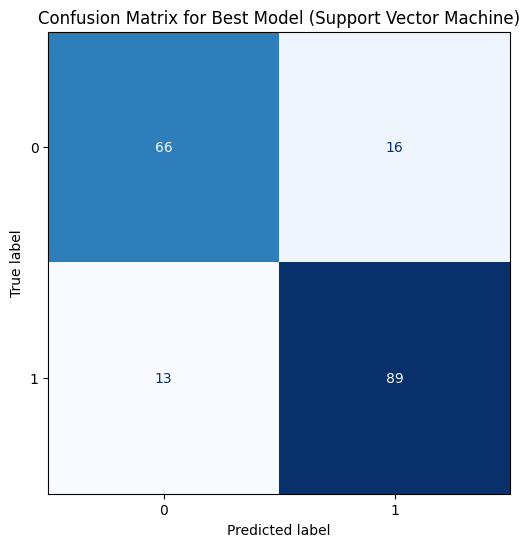

In [ ]:
best_score = 0
best_model = None
best_model_name = None
best_metrics = {}

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\nModel: {name}")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1-score : {f1:.4f}")


    if recall > best_score:
        best_score = recall
        best_model = model
        best_model_name = name
        best_metrics = {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

print("\n Best Model (based on Recall):")
print(f"Model: {best_model_name}")
for metric, value in best_metrics.items():
    print(f"  {metric.capitalize()}: {value:.4f}")


y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f'Confusion Matrix for Best Model ({best_model_name})')
plt.show()